# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [21]:
#Question 1-1

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Question 1A ----------------
airbnb = pd.read_csv("/content/airbnb_hw.csv")

airbnb["Price"].dtype #checking to see whether the price is current treated as a integer or not --- treated as a object

# Stripping Data
airbnb["Price"] = airbnb["Price"].str.replace("$", "", regex=False) #removing the dollar sign from the Price values
airbnb["Price"] = airbnb["Price"].str.replace(",", "", regex = False) #removing commas from Price values
#removing dollar sign and commas because they prevent Python from treating the value as a normal number

# Converting Price values from text to numerical
airbnb["Price"] = pd.to_numeric(airbnb["Price"], errors="coerce")
# errors="coerce" changes anything that cannot be converted to a numerical value to NaN (missing value)

airbnb["Price"].head(20) # Price values are now be numbers and are cleaned
print(airbnb["Price"].head(20)) #checking cleaned values

print("Total Missing Values:", airbnb["Price"].isna().sum())
#This prints the number of missing Price Values, now that the data is cleaned, it is 0



0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: int64
Total Missing Values: 0


Questions 1-1: There are 0 missing values
left.




In [22]:
#Question 1-2
mn_police = pd.read_csv("/content/mn_police_use_of_force.csv")
#loading Minnesota police dataset & naming it

#investigating data
mn_police.head()#checking the first 5 rows to see what dataset looks like
mn_police.columns#checking the columns name

print(mn_police['subject_injury'].value_counts(dropna=False))
#output shows 9848 missing values, 1631 Yes, 1446 No

#cleaning data
mn_police["subject_clean"] = mn_police["subject_injury"].astype(str)#converting values to string
mn_police["subject_clean"] = mn_police["subject_injury"].str.strip()#removing unecessary spaces

mn_police_clean = mn_police.dropna(subset=['subject_clean'])
#removing the missing subject_injury observations, only Yes and No now

print("Dataset without Missing Values:", mn_police_clean["subject_clean"].value_counts())
#checking to make sure the NaN is removed


#finding the proportion of values that are missing from the dataset with Yes, No, Nan (missing data)
missing_proportion = mn_police['subject_clean'].isna().mean() #find the proportion of missing values
print("Proportion Missing: ", missing_proportion) #prints the proportion of missing values
print("Percentage Missing:", missing_proportion*100) #prints the percentage of missing values


#cross-tabulate injury data with force data
pd.crosstab(mn_police['subject_clean'],mn_police['force_type'], dropna=False)
#evaluating the amount of missing data from each different force type



subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64
Dataset without Missing Values: subject_clean
Yes    1631
No     1446
Name: count, dtype: int64
Proportion Missing:  0.7619342359767892
Percentage Missing: 76.19342359767892


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_clean,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


Question 1-2:

What proportion of values are missing? Is this a concern?

This is concerning. A missing proportion of 76% means the majority of observations do not have information about whether the subject was injured or not. This is very limiting to the reliablility of analyses using subject_injury. It is important to check whether the missing values are concentrated in a specific force type or not because this could indicate that the missingness issue is not random.


Are there any patterns regarding when the data are missing?

The table shows that missingness is not evenly distributed. There is large amounts of missing data for the innjurt types: Bodily Force, Chemical Irritant, Taser, and Maximal Restraint Technique. In addition to this, some force types have none or almost no missingness: Firearm, Less Lethal Projectile, Police K9 Bite, and Baton. This pattern is very important as it suggests that missingness may be related to force type rather than being entirely random. This is concerning for analyses involving subject_injury.



Proportion of Male Victims:  80.1461289869327
Proportion of Unprovoked Attacks:  73.94969790642124


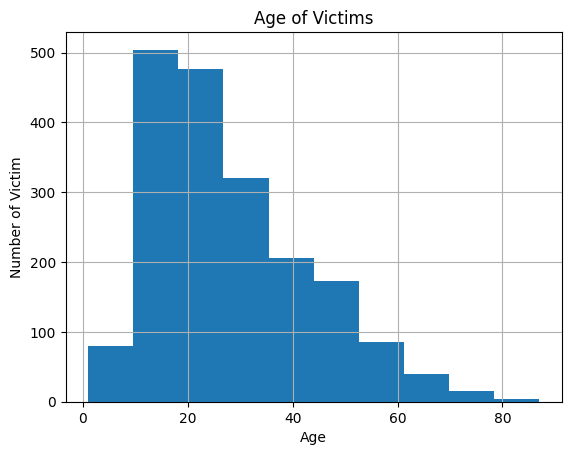

In [23]:
#Question 2-1


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

incident_log = pd.read_excel("/content/GSAF5.xls")
#importing incident log excel file

incident_log.dropna(how='all', axis = 1, inplace = True)
#dropping columns without data

incident_log["Year"].dtype
#checking to see whether the year treated as an integer or float - treated as a float


#Cleaning the Year variable

incident_log['Year']=pd.to_numeric(incident_log['Year'], errors='coerce')
#converting the Year variable from a float to a number

#Finding range of values
incident_log['Year'].min() #finding the lowest year, output = zero
incident_log['Year'].max() #finding the highest year, output = 2026


#filter the rows to focus on attacks since 1940
filter = incident_log['Year'] >= 1940
incident_log[filter]

#Naming variable to count attacks per year after 1940
attacks_per_year_1940 = incident_log[filter]['Year'].value_counts().sort_index()

#Making visual to see if attacks are increasing, decrasing, or constant between 1940-2026
#attacks_per_year_1940.plot()
#plt.xlabel('Year')
#plt.ylabel('Number of Attacks')
#plt.title('Shark Attacks Since 1940')
#plt.show


#Cleaning the Age variable

incident_log['Age'].dtype #checking to see the data type of the age variable - it is an object

incident_log['Age'] = incident_log['Age'].str.replace('+','', regex=False) #removing "+" from the Age variable ex. "50+" "
incident_log['Age'] = incident_log['Age'].str.replace("'s",'', regex=False) #removing "'s" from the Age variable ex. "50's"

incident_log['Age'] = pd.to_numeric(incident_log["Age"], errors='coerce')
#converting from object to numeric and missing values to NaN

incident_log['Age'].dtype #checking to make sure converted to numeric

#Creating a histogram
incident_log['Age'].hist()
plt.xlabel('Age') #Labeling x-axis
plt.ylabel('Number of Victim') #Labeling y-axis
plt.title('Age of Victims') #creating title of histogram


#Finding the proportion of male victims
male_proportion = ((incident_log['Sex'] == 'M').mean()) * 100
#searching through the 'Sex' variable for M (male) values and multiplying that count by 100 to get the proportion

print("Proportion of Male Victims: ",male_proportion) #printing the proportion

#Cleaning the type variable


incident_log["Type"].dtype #checking data type, treated as an object
(incident_log['Type'].value_counts()) #checking what different values there are

incident_log["Type"] =incident_log['Type'].str.strip()#removing unecessary spaces

(incident_log['Type'].value_counts()) #checking now again what different values there are


#Condensing into 3 variable: Provoked, Unprovoked, Unknown

incident_log.loc[incident_log['Type'].str.lower() == 'unprovoked', 'Type'] = 'Unprovoked'
#making the UNprovoked, unprovoked, and Unprovoked values all the same

incident_log.loc[
    (incident_log['Type'] != 'Provoked') &
    (incident_log['Type'] != 'Unprovoked'),
    'Type'
] = 'Unknown' #creating the variable Unknown for all values that are not Unprovoked and Provoked

incident_log['Type'].value_counts() #checking to see if types are now Unprovoked, Provoked, and Unknown

#Finding the proportion of attacks that are Unprovoked

unprovoked_attacks = ((incident_log['Type'] == 'Unprovoked').mean()) * 100
print('Proportion of Unprovoked Attacks: ',unprovoked_attacks)



Question 2:


**Clean the year variable and Describe the range of values you see:**
The year variable ranges from 0 to 2026.


**Are attacks increasing, decreasing, or remaining constant over time?**

Between 1940 and 2026, the shark attacks are increasing from 1940 to 1960, decreasing from 1960 to 1980, increaings from 1980 to around 2010, and the decreasing from 2010 to 2026. However, all time without the filter at 1940, the attack are around 0 until 1750 and then simply increase exponentially.



**What proportion of victims are male?**

Around 80% of victims are male



**What proportion of attacks are unprovoked?**

Around 73% of attacks are unprovoked

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. ...




### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]



### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|




### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]